## CNN *from scratch* vs Transfer Learning sur données d'images Cats vs Dogs

Cours : Deep Learning (DIT)

**Auteur : Josias AHOGA**

Ce notebook se déroule en deux temps :

**Partie 1** :chargement des images avec `ImageFolder`, définition des
   transformations (avec justification), augmentation de données et
   visualisation.

**Partie 2** : comparaison d'un CNN entraîné *from scratch* et d'un modèle
   en *transfer learning* (ResNet18), avec suivi des métriques, comparaison de
   deux optimiseurs, recherche du learning rate, sauvegarde/rechargement du
   meilleur modèle, matrice de confusion et analyse.

Le jeu de données est celui de (*Cats vs Dogs*), déjà séparé en
`train/` et `test/`, chaque dossier contenant deux sous-dossiers `cat/` et `dog/`.


# Partie 1 : Chargement et préparation des données

## 1.1 Montage du Drive et mise en place de l'environnement

Les données et le code sont stockés sur Google Drive. Pour éviter la lenteur de
lecture directe depuis le Drive (des milliers de petites images), on copie
l'archive sur le disque local de la session Colab puis on la décompresse :
la lecture devient alors rapide pendant tout l'entraînement.


In [3]:
# Montage du Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os, shutil, time

DRIVE = "/content/drive/MyDrive/TP_CNN"   # ton dossier Drive

# Copier le zip depuis le Drive vers le disque local (rapide : 1 seul fichier)
t0 = time.time()
shutil.copy(os.path.join(DRIVE, "cat-dog-data.zip"), "/content/cat-dog-data.zip")
print("Copie du zip :", round(time.time() - t0, 1), "s")

# Décompresser en local (très rapide)
t0 = time.time()
!unzip -q /content/cat-dog-data.zip -d /content/
print("Décompression :", round(time.time() - t0, 1), "s")

# Vérifier ce qui a été extrait
print("Contenu de /content :", os.listdir("/content"))

Copie du zip : 15.9 s
Décompression : 7.1 s
Contenu de /content : ['.config', 'Cat_Dog_data', 'drive', 'cat-dog-data.zip', 'sample_data']


In [5]:
# Vérification du GPU : l'entraînement doit tourner sur GPU si disponible.
import torch
print("PyTorch :", torch.__version__)
print("GPU disponible :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Carte :", torch.cuda.get_device_name(0))

PyTorch : 2.11.0+cu128
GPU disponible : True
Carte : Tesla T4


## 1.2 Reproductibilité (seed)

On fixe une graine aléatoire unique pour Python, NumPy et PyTorch afin que les
résultats soient reproductibles d'une exécution à l'autre.


In [6]:
import random
import numpy as np
import torch

SEED = 42

def set_seed(seed=42):
    # Fixe toutes les sources d'aléa pour la reproductibilité
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# Choix du device une fois pour toutes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Entraînement sur :", device)

Entraînement sur : cuda


## 1.3 Chargement de base avec `ImageFolder`

`datasets.ImageFolder` attend une arborescence où chaque classe a son propre
dossier :

```
Cat_Dog_data/train/cat/xxx.jpg
Cat_Dog_data/train/dog/yyy.jpg
```

Les images sont automatiquement étiquetées d'après le nom du dossier.
On commence par un chargement simple du dossier d'entraînement, comme dans le
notebook du cours.


In [7]:
from torchvision import datasets, transforms

data_dir = "/content/Cat_Dog_data/train"

# Pipeline de transformations minimal :
#  - Resize(255)      : redimensionne le plus petit côté à 255 pixels
#  - CenterCrop(224)  : recadre au centre en 224x224 (taille attendue par le modèle)
#  - ToTensor()       : convertit l'image PIL en tenseur PyTorch (valeurs entre 0 et 1)
transform = transforms.Compose([
    transforms.Resize(255),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

# Création du dataset à partir du dossier, en appliquant les transformations
dataset = datasets.ImageFolder(data_dir, transform=transform)

# Le DataLoader fournit les images par lots (batches) et peut les mélanger
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

print("Nombre d'images :", len(dataset))
print("Classes :", dataset.classes)

Nombre d'images : 22500
Classes : ['cat', 'dog']


### Fonction utilitaire d'affichage

Cette fonction permet d'afficher un tenseur image. Elle
inverse la normalisation si nécessaire pour obtenir un rendu lisible.


In [8]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(image, ax=None, title=None, normalize=True):
    # Affichage d'un tenseur image (tenseur PyTorch -> matplotlib)
    if ax is None:
        fig, ax = plt.subplots()

    # Les tenseurs PyTorch sont au format (canaux, hauteur, largeur).
    # matplotlib attend (hauteur, largeur, canaux) -> on transpose.
    image = image.numpy().transpose((1, 2, 0))

    if normalize:
        # Inversion de la normalisation ImageNet pour un affichage correct
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='both', length=0)
    ax.set_xticklabels('')
    ax.set_yticklabels('')
    if title:
        ax.set_title(title)
    return ax

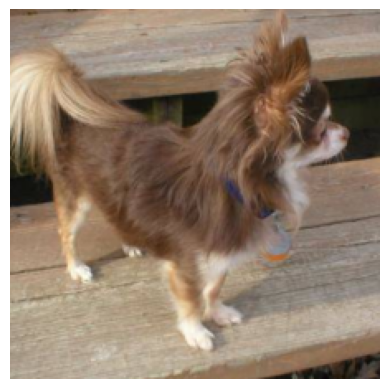

Forme d'un lot d'images : torch.Size([32, 3, 224, 224])


In [9]:
# Test du DataLoader : on récupère un lot et on affiche la première image.
images, labels = next(iter(dataloader))
imshow(images[0], normalize=False)
plt.show()
print("Forme d'un lot d'images :", images.shape)  # (32, 3, 224, 224)

## 1.4 Transformations : entraînement vs test (avec justification)

### Pourquoi des transformations différentes ?

**Pour l'entraînement**, on applique de l'**augmentation de données** : rotation,
recadrage aléatoire et retournement horizontal. À chaque époque, le réseau voit
donc une version légèrement différente de chaque image. Cela revient à agrandir
artificiellement le jeu de données et **aide le modèle à mieux généraliser**
(il devient robuste aux changements de position, d'orientation et de cadrage).

**Pour le test (et la validation)**, on ne déforme pas les images : on se contente
de les redimensionner et de les recadrer au centre. L'évaluation doit en effet se
faire sur des images « normales », représentatives de ce que le modèle verra en
production. Appliquer de l'aléatoire au test fausserait la mesure.

### Pourquoi normaliser ?

`transforms.Normalize(mean, std)` applique, pour chaque canal de couleur :

```
pixel_normalisé = (pixel - moyenne) / écart-type
```

Soustraire la moyenne recentre les valeurs autour de zéro, diviser par
l'écart-type les met à une échelle comparable. Cela **stabilise l'apprentissage**
et rend la rétropropagation plus efficace. On utilise ici les statistiques du
jeu **ImageNet** (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`),
car le modèle de transfer learning (ResNet18) a été pré-entraîné avec ces
valeurs : il faut lui présenter les images normalisées de la même façon.


In [10]:
# Statistiques de normalisation ImageNet (standard pour les modèles pré-entraînés)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transformations d'ENTRAÎNEMENT : avec augmentation de données
train_transforms = transforms.Compose([
    transforms.RandomRotation(30),               # rotation aléatoire +/- 30°
    transforms.RandomResizedCrop(224),           # recadrage + redimensionnement aléatoires
    transforms.RandomHorizontalFlip(),           # retournement horizontal aléatoire
    transforms.ToTensor(),                       # conversion en tenseur
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),  # normalisation
])

# Transformations de TEST : pas d'augmentation, seulement resize + crop + normalisation
test_transforms = transforms.Compose([
    transforms.Resize(255),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Transformations définies.")

Transformations définies.


## 1.5 Split train / validation 

Le jeu fourni contient `train/` et `test/`. Pour suivre
l'apprentissage, on réserve une partie du `train/` comme **jeu de validation**
(20 %). Le `test/` n'est utilisé qu'à la toute fin, pour l'évaluation finale.

Le découpage est **stratifié** (on garde la même proportion de chats et de
chiens dans train et val) et **reproductible** (basé sur le seed).


In [11]:
from torch.utils.data import DataLoader, Subset

data_dir = "/content/Cat_Dog_data"
BATCH_SIZE = 32
VAL_SPLIT  = 0.2

# On crée deux vues du dossier train :
#  - une avec augmentation (pour l'entraînement)
#  - une sans augmentation (pour la validation, qui doit rester "propre")
train_full_aug  = datasets.ImageFolder(data_dir + "/train", transform=train_transforms)
train_full_eval = datasets.ImageFolder(data_dir + "/train", transform=test_transforms)
test_data       = datasets.ImageFolder(data_dir + "/test",  transform=test_transforms)

classes = train_full_aug.classes
print("Classes :", classes)

# Découpage stratifié train / validation
targets = np.array(train_full_aug.targets)
rng = np.random.default_rng(SEED)
train_idx, val_idx = [], []
for c in np.unique(targets):
    idx_c = np.where(targets == c)[0]
    rng.shuffle(idx_c)
    n_val = int(round(len(idx_c) * VAL_SPLIT))
    val_idx.extend(idx_c[:n_val].tolist())
    train_idx.extend(idx_c[n_val:].tolist())

train_data = Subset(train_full_aug,  train_idx)
val_data   = Subset(train_full_eval, val_idx)

# DataLoaders
trainloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
valloader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
testloader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"train = {len(train_data)} | val = {len(val_data)} | test = {len(test_data)}")

Classes : ['cat', 'dog']
train = 18000 | val = 4500 | test = 2500


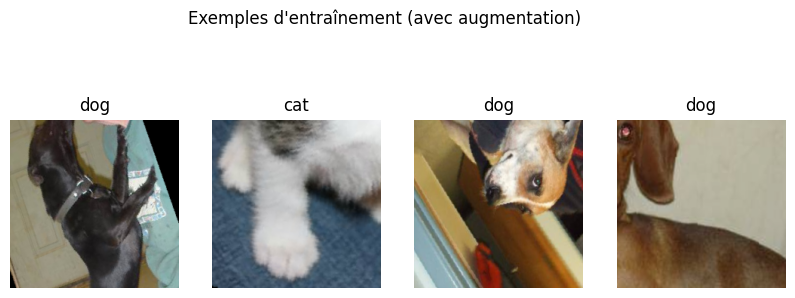

In [12]:
# Visualisation d'un lot d'images d'entraînement (après augmentation).
data_iter = iter(trainloader)
images, labels = next(data_iter)

fig, axes = plt.subplots(figsize=(10, 4), ncols=4)
for ii in range(4):
    ax = axes[ii]
    imshow(images[ii], ax=ax, normalize=True, title=classes[labels[ii]])
plt.suptitle("Exemples d'entraînement (avec augmentation)")
plt.show()

# Partie 2 : TP : CNN *from scratch* vs Transfer Learning

## Objectif

Comparer deux approches sur le même jeu *Cats vs Dogs* :

- **Expérience A** : un CNN construit et entraîné **from scratch** (au moins 3
  blocs de convolution), avec **BatchNorm** et **Dropout**.
- **Expérience B** : un modèle en **transfer learning** (ResNet18 pré-entraîné
  sur ImageNet), dont on adapte la couche finale.

Pour chaque approche, on suit à chaque époque : **loss, accuracy, précision,
recall**. On teste **deux optimiseurs** (Adam et SGD), on cherche un bon
**learning rate**, on utilise un **scheduler** , on **sauvegarde** le
meilleur modèle puis on le **recharge** pour le test final, et on trace la
**matrice de confusion** .


## 2.1 Fonctions d'entraînement et d'évaluation

On définit des fonctions réutilisables :

- `run_epoch` exécute une époque (entraînement si un optimiseur est fourni,
  sinon évaluation) et renvoie loss, accuracy, précision et recall.
- `fit` enchaîne les époques, applique le scheduler, et **sauvegarde le meilleur
  modèle** d'après l'accuracy de validation.
- `evaluate_full` réalise l'évaluation finale avec la matrice de confusion.


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import time

def run_epoch(model, loader, criterion, optimizer=None):
    # Exécute une époque : entraînement si optimizer fourni, sinon évaluation
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, n = 0.0, 0
    y_true_all, y_pred_all = [], []

    # En évaluation, on désactive le calcul du gradient (plus rapide, moins de mémoire)
    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if is_train:
                optimizer.zero_grad()        # remise à zéro des gradients

            outputs = model(images)          # passe avant
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()              # rétropropagation
                optimizer.step()             # mise à jour des poids

            total_loss += loss.item() * images.size(0)
            n += images.size(0)
            preds = outputs.argmax(dim=1)
            y_pred_all.append(preds.cpu().numpy())
            y_true_all.append(labels.cpu().numpy())

    y_pred = np.concatenate(y_pred_all)
    y_true = np.concatenate(y_true_all)
    return {
        "loss":      total_loss / n,
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall":    recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

In [14]:
def fit(model, trainloader, valloader, epochs, optimizer, scheduler=None,
        checkpoint_path="best_model.pth", tag="model"):
    # Boucle d'entraînement complète ; sauvegarde le meilleur modèle (val accuracy)
    model.to(device)
    criterion = torch.nn.CrossEntropyLoss()

    # Historique des métriques pour tracer les courbes ensuite
    history = {k: [] for k in
               ["train_loss", "val_loss", "train_acc", "val_acc",
                "train_prec", "val_prec", "train_rec", "val_rec", "lr"]}
    best_val_acc = 0.0

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr = run_epoch(model, trainloader, criterion, optimizer)   # entraînement
        va = run_epoch(model, valloader,  criterion, optimizer=None)  # validation

        if scheduler is not None:
            scheduler.step()
        lr = optimizer.param_groups[0]["lr"]

        # Enregistrement de l'historique
        history["train_loss"].append(tr["loss"]);  history["val_loss"].append(va["loss"])
        history["train_acc"].append(tr["accuracy"]); history["val_acc"].append(va["accuracy"])
        history["train_prec"].append(tr["precision"]); history["val_prec"].append(va["precision"])
        history["train_rec"].append(tr["recall"]); history["val_rec"].append(va["recall"])
        history["lr"].append(lr)

        # Sauvegarde du meilleur modèle
        if va["accuracy"] > best_val_acc:
            best_val_acc = va["accuracy"]
            torch.save({"model_state": model.state_dict(),
                        "val_acc": best_val_acc, "epoch": epoch}, checkpoint_path)

        print(f"[{tag}] époque {epoch:02d}/{epochs} | "
              f"train loss {tr['loss']:.4f} acc {tr['accuracy']:.4f} | "
              f"val loss {va['loss']:.4f} acc {va['accuracy']:.4f} "
              f"prec {va['precision']:.4f} rec {va['recall']:.4f} | "
              f"lr {lr:.2e} | {time.time()-t0:.0f}s")

    print(f"[{tag}] meilleure val accuracy = {best_val_acc:.4f} "
          f"(sauvegardée dans {checkpoint_path})")
    return history, best_val_acc

In [15]:
def evaluate_full(model, loader):
    # Évaluation finale : métriques globales + matrice de confusion
    model.eval()
    y_true_all, y_pred_all = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            preds = model(images).argmax(dim=1).cpu().numpy()
            y_pred_all.append(preds)
            y_true_all.append(labels.numpy())
    y_pred = np.concatenate(y_pred_all)
    y_true = np.concatenate(y_true_all)
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall":    recall_score(y_true, y_pred, average="macro", zero_division=0),
        "cm":        confusion_matrix(y_true, y_pred),
        "y_true": y_true, "y_pred": y_pred,
    }

def plot_history(history, title=""):
    # Trace loss, accuracy, précision et recall (train vs validation)
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    panels = [("loss", "Loss"), ("acc", "Accuracy"),
              ("prec", "Précision"), ("rec", "Recall")]
    for ax, (key, label) in zip(axes.ravel(), panels):
        ax.plot(epochs, history[f"train_{key}"], "o-", label="train")
        ax.plot(epochs, history[f"val_{key}"],   "s-", label="validation")
        ax.set_xlabel("Époque"); ax.set_ylabel(label); ax.set_title(label)
        ax.legend(); ax.grid(alpha=0.3)
    fig.suptitle(title); fig.tight_layout()
    plt.show()

## 2.2 Recherche du learning rate (LR finder)

Avant d'entraîner, on cherche un ordre de grandeur raisonnable pour le learning
rate. On augmente progressivement le LR sur quelques dizaines de lots et on
observe la loss : le bon LR se situe dans la zone où la loss décroît le plus
vite, juste avant qu'elle ne reparte à la hausse.


In [16]:
import torch.nn as nn

def lr_finder(build_fn, loader, init_lr=1e-7, final_lr=1.0, n_steps=80):
    # Balaye le learning rate de façon exponentielle ; renvoie (lrs, losses)
    model = build_fn().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=init_lr)
    criterion = nn.CrossEntropyLoss()
    gamma = (final_lr / init_lr) ** (1 / n_steps)

    lrs, losses = [], []
    model.train()
    it = iter(loader)
    lr = init_lr
    for step in range(n_steps):
        try:
            x, y = next(it)
        except StopIteration:
            it = iter(loader); x, y = next(it)
        x, y = x.to(device), y.to(device)

        for g in optimizer.param_groups:
            g["lr"] = lr
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward(); optimizer.step()

        lrs.append(lr); losses.append(loss.item())
        if step > 5 and loss.item() > 4 * min(losses):
            break          # la loss explose, on arrête
        lr *= gamma
    return lrs, losses

## 2.3 Expérience A : CNN *from scratch*

### Architecture

Le réseau comporte **4 blocs de convolution**. Chaque bloc applique :
`Conv -> BatchNorm -> ReLU -> Conv -> BatchNorm -> ReLU -> MaxPool`.

- **BatchNorm** (après chaque convolution) normalise les activations. Cela
  stabilise et accélère l'apprentissage et permet d'utiliser des learning rates
  plus élevés.
- **MaxPool** réduit de moitié la taille spatiale à chaque bloc
  (224 → 112 → 56 → 28 → 14).

La tête de classification utilise du **Dropout** pour limiter le surapprentissage
(elle « éteint » aléatoirement des neurones pendant l'entraînement, ce qui évite
que le réseau ne dépende trop de quelques connexions).


In [17]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    # CNN from scratch : 4 blocs convolutifs + tête dense avec Dropout

    def __init__(self, num_classes=2, dropout=0.5):
        super().__init__()

        def conv_block(in_c, out_c):
            # Bloc : 2 convolutions (BatchNorm + ReLU chacune) puis MaxPool
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            conv_block(3, 32),     # bloc 1 : 224 -> 112
            conv_block(32, 64),    # bloc 2 : 112 -> 56
            conv_block(64, 128),   # bloc 3 : 56  -> 28
            conv_block(128, 256),  # bloc 4 : 28  -> 14
        )
        self.pool = nn.AdaptiveAvgPool2d(1)   # réduit chaque carte à 1x1

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),              # régularisation
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

# Petit test de cohérence des dimensions
set_seed(SEED)
_m = SimpleCNN()
_out = _m(torch.randn(2, 3, 224, 224))
print("Sortie du CNN :", _out.shape, "(doit être [2, 2])")
del _m, _out

Sortie du CNN : torch.Size([2, 2]) (doit être [2, 2])


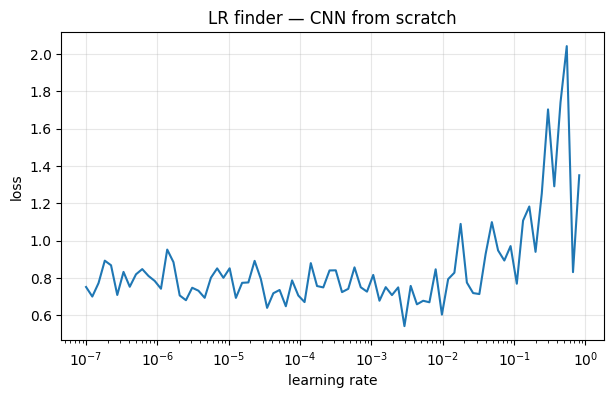

On choisit un LR situé dans la zone de descente la plus forte (ici ~1e-3).


In [18]:
# Recherche du learning rate pour le CNN from scratch
set_seed(SEED)
lrs, losses = lr_finder(lambda: SimpleCNN(dropout=0.5), trainloader)

plt.figure(figsize=(7, 4))
plt.plot(lrs, losses)
plt.xscale("log")
plt.xlabel("learning rate"); plt.ylabel("loss")
plt.title("LR finder - CNN from scratch")
plt.grid(alpha=0.3); plt.show()
print("On choisit un LR situé dans la zone de descente la plus forte (ici ~1e-3).")

### 2.3.1 Entraînement *from scratch* avec **Adam** + scheduler cosine

Premier optimiseur : **Adam**, réputé pour converger rapidement. On ajoute un
**scheduler** `CosineAnnealingLR` qui fait décroître progressivement le learning
rate au fil des époques (bonus).


In [19]:
EPOCHS_SCRATCH = 25

set_seed(SEED)
model_scratch_adam = SimpleCNN(num_classes=2, dropout=0.5)
optimizer = torch.optim.Adam(model_scratch_adam.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_SCRATCH)

hist_scratch_adam, best_scratch_adam = fit(
    model_scratch_adam, trainloader, valloader,
    epochs=EPOCHS_SCRATCH, optimizer=optimizer, scheduler=scheduler,
    checkpoint_path="scratch_adam.pth", tag="scratch+Adam",
)

[scratch+Adam] époque 01/25 | train loss 0.6782 acc 0.5841 | val loss 0.6323 acc 0.6520 prec 0.6656 rec 0.6520 | lr 9.96e-04 | 131s
[scratch+Adam] époque 02/25 | train loss 0.6445 acc 0.6242 | val loss 0.6256 acc 0.6447 prec 0.6506 rec 0.6447 | lr 9.84e-04 | 132s
[scratch+Adam] époque 03/25 | train loss 0.6211 acc 0.6567 | val loss 0.6325 acc 0.6513 prec 0.6841 rec 0.6513 | lr 9.65e-04 | 133s
[scratch+Adam] époque 04/25 | train loss 0.6084 acc 0.6700 | val loss 0.5700 acc 0.6982 prec 0.7189 rec 0.6982 | lr 9.38e-04 | 132s
[scratch+Adam] époque 05/25 | train loss 0.5968 acc 0.6833 | val loss 0.5484 acc 0.7300 prec 0.7315 rec 0.7300 | lr 9.05e-04 | 132s
[scratch+Adam] époque 06/25 | train loss 0.5800 acc 0.6999 | val loss 0.5225 acc 0.7411 prec 0.7524 rec 0.7411 | lr 8.64e-04 | 132s
[scratch+Adam] époque 07/25 | train loss 0.5679 acc 0.7124 | val loss 0.5711 acc 0.6807 prec 0.7494 rec 0.6807 | lr 8.19e-04 | 133s
[scratch+Adam] époque 08/25 | train loss 0.5527 acc 0.7189 | val loss 0.4642

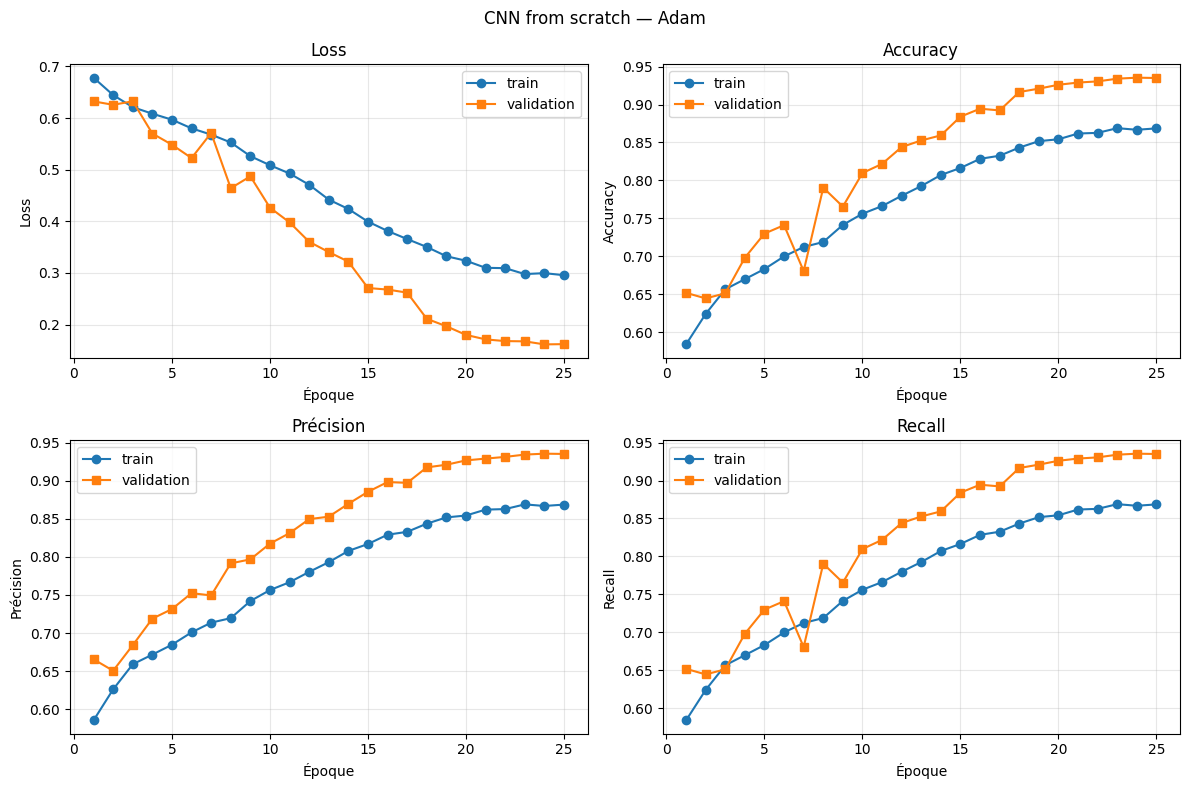

In [20]:
plot_history(hist_scratch_adam, "CNN from scratch - Adam")

### 2.3.2 Deuxième optimiseur : **SGD** + scheduler StepLR

On ré-entraîne la même
architecture avec **SGD** (avec momentum). `StepLR` divise le learning rate par
10 à intervalles réguliers.


In [21]:
set_seed(SEED)
model_scratch_sgd = SimpleCNN(num_classes=2, dropout=0.5)
optimizer = torch.optim.SGD(model_scratch_sgd.parameters(), lr=1e-2,
                            momentum=0.9, nesterov=True, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

hist_scratch_sgd, best_scratch_sgd = fit(
    model_scratch_sgd, trainloader, valloader,
    epochs=EPOCHS_SCRATCH, optimizer=optimizer, scheduler=scheduler,
    checkpoint_path="scratch_sgd.pth", tag="scratch+SGD",
)

[scratch+SGD] époque 01/25 | train loss 0.7012 acc 0.5630 | val loss 0.6074 acc 0.6811 prec 0.6813 rec 0.6811 | lr 1.00e-02 | 131s
[scratch+SGD] époque 02/25 | train loss 0.6538 acc 0.6280 | val loss 0.5862 acc 0.6982 prec 0.7030 rec 0.6982 | lr 1.00e-02 | 132s
[scratch+SGD] époque 03/25 | train loss 0.6283 acc 0.6570 | val loss 0.5809 acc 0.7033 prec 0.7100 rec 0.7033 | lr 1.00e-02 | 131s
[scratch+SGD] époque 04/25 | train loss 0.6213 acc 0.6627 | val loss 0.5718 acc 0.7009 prec 0.7197 rec 0.7009 | lr 1.00e-02 | 131s
[scratch+SGD] époque 05/25 | train loss 0.6068 acc 0.6822 | val loss 0.6168 acc 0.6647 prec 0.7016 rec 0.6647 | lr 1.00e-03 | 131s
[scratch+SGD] époque 06/25 | train loss 0.5696 acc 0.7074 | val loss 0.5133 acc 0.7460 prec 0.7460 rec 0.7460 | lr 1.00e-03 | 133s
[scratch+SGD] époque 07/25 | train loss 0.5605 acc 0.7156 | val loss 0.4877 acc 0.7651 prec 0.7660 rec 0.7651 | lr 1.00e-03 | 133s
[scratch+SGD] époque 08/25 | train loss 0.5525 acc 0.7174 | val loss 0.4924 acc 0.7

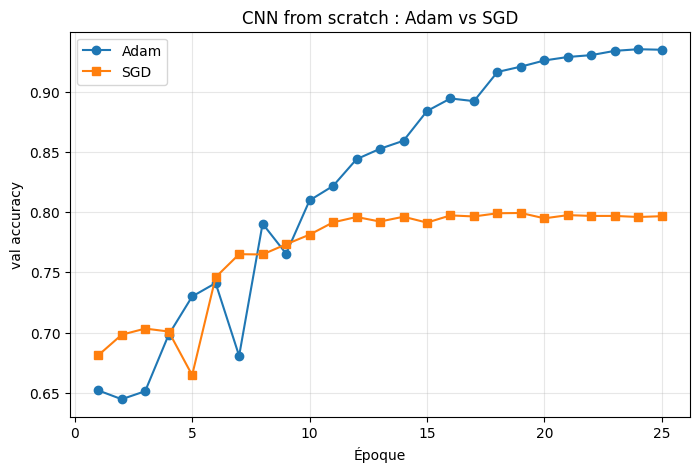

Meilleure val accuracy — Adam : 0.9353 | SGD : 0.7993


In [22]:
# Comparaison des deux optimiseurs sur l'architecture from scratch
plt.figure(figsize=(8, 5))
ep = range(1, EPOCHS_SCRATCH + 1)
plt.plot(ep, hist_scratch_adam["val_acc"], "o-", label="Adam")
plt.plot(ep, hist_scratch_sgd["val_acc"],  "s-", label="SGD")
plt.xlabel("Époque"); plt.ylabel("val accuracy")
plt.title("CNN from scratch : Adam vs SGD")
plt.legend(); plt.grid(alpha=0.3); plt.show()

print(f"Meilleure val accuracy - Adam : {best_scratch_adam:.4f} | SGD : {best_scratch_sgd:.4f}")

## 2.4 Expérience B : Transfer Learning (ResNet18)

On part d'un **ResNet18 pré-entraîné sur ImageNet**. Ce réseau a déjà appris à
extraire des caractéristiques visuelles utiles (contours, textures, formes). On
**gèle** ses poids (ils ne seront pas modifiés) et on remplace seulement la
dernière couche par une nouvelle tête à 2 sorties (chat / chien) avec Dropout.
Seule cette tête est entraînée : c'est rapide et très efficace.



In [23]:
from torchvision import models

def build_resnet18(num_classes=2, dropout=0.4, freeze=True):
    # ResNet18 pré-entraîné, avec une nouvelle tête de classification
    # weights=... télécharge les poids ImageNet (nécessite Internet, OK sur Colab)
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze:
        # On gèle tout le réseau : ses poids ne seront pas mis à jour
        for p in model.parameters():
            p.requires_grad = False

    # On remplace la couche finale (fc) par notre tête à 2 classes
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes),
    )
    return model

# Vérification
set_seed(SEED)
_m = build_resnet18()
n_trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print("Paramètres entraînables (tête seule) :", f"{n_trainable:,}")
del _m

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s]


Paramètres entraînables (tête seule) : 1,026


### 2.4.1 Transfer learning avec **Adam**

[transfer+Adam] époque 01/10 | train loss 0.2709 acc 0.8788 | val loss 0.0837 acc 0.9662 prec 0.9674 rec 0.9662 | lr 9.76e-04 | 94s
[transfer+Adam] époque 02/10 | train loss 0.2314 acc 0.8965 | val loss 0.0681 acc 0.9780 prec 0.9780 rec 0.9780 | lr 9.05e-04 | 94s
[transfer+Adam] époque 03/10 | train loss 0.2337 acc 0.8952 | val loss 0.0760 acc 0.9704 prec 0.9713 rec 0.9704 | lr 7.94e-04 | 96s
[transfer+Adam] époque 04/10 | train loss 0.2285 acc 0.8990 | val loss 0.0656 acc 0.9764 prec 0.9766 rec 0.9764 | lr 6.55e-04 | 94s
[transfer+Adam] époque 05/10 | train loss 0.2334 acc 0.8957 | val loss 0.0688 acc 0.9727 prec 0.9731 rec 0.9727 | lr 5.00e-04 | 95s
[transfer+Adam] époque 06/10 | train loss 0.2229 acc 0.9027 | val loss 0.0724 acc 0.9711 prec 0.9718 rec 0.9711 | lr 3.45e-04 | 96s
[transfer+Adam] époque 07/10 | train loss 0.2219 acc 0.9006 | val loss 0.0658 acc 0.9769 prec 0.9769 rec 0.9769 | lr 2.06e-04 | 95s
[transfer+Adam] époque 08/10 | train loss 0.2145 acc 0.9053 | val loss 0.071

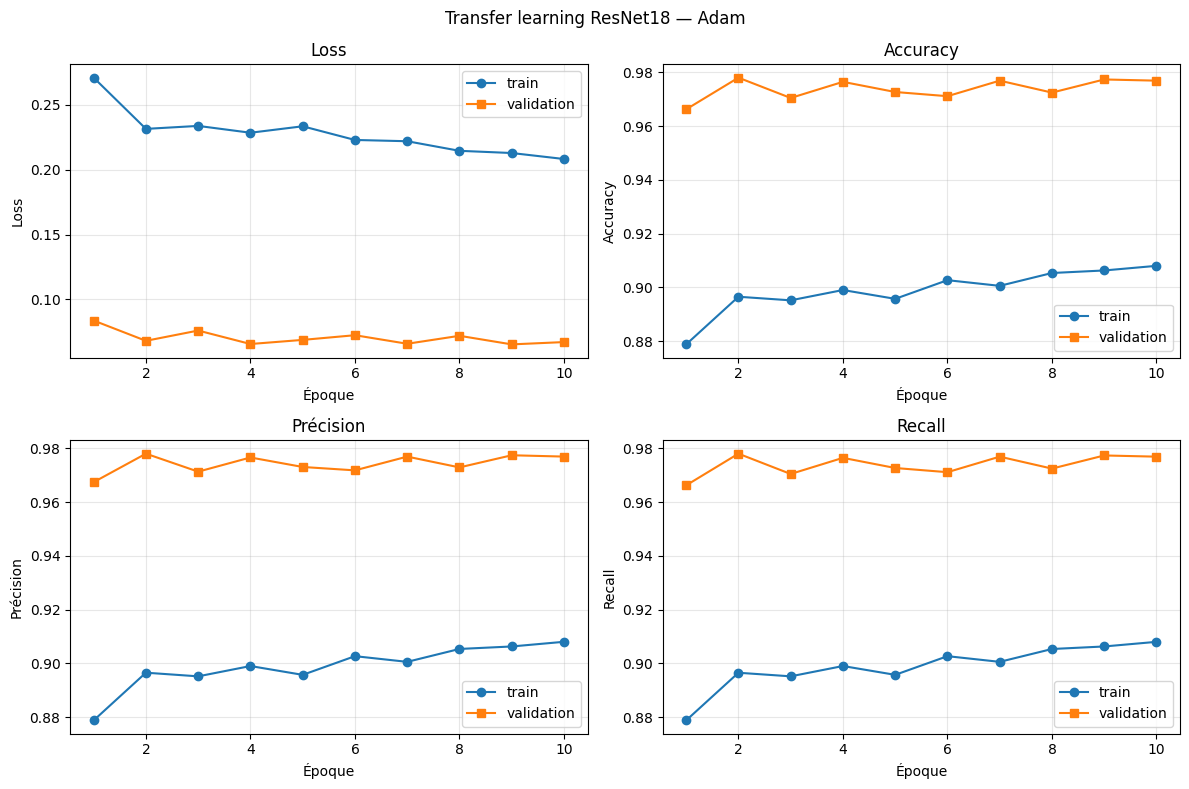

In [24]:
EPOCHS_TF = 10

set_seed(SEED)
model_tf_adam = build_resnet18(num_classes=2, dropout=0.4, freeze=True)
# On n'optimise que les paramètres entraînables (la nouvelle tête)
params = [p for p in model_tf_adam.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(params, lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_TF)

hist_tf_adam, best_tf_adam = fit(
    model_tf_adam, trainloader, valloader,
    epochs=EPOCHS_TF, optimizer=optimizer, scheduler=scheduler,
    checkpoint_path="transfer_adam.pth", tag="transfer+Adam",
)
plot_history(hist_tf_adam, "Transfer learning ResNet18 - Adam")

### 2.4.2 Transfer learning avec **SGD**

In [25]:
set_seed(SEED)
model_tf_sgd = build_resnet18(num_classes=2, dropout=0.4, freeze=True)
params = [p for p in model_tf_sgd.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=1e-2, momentum=0.9, nesterov=True, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

hist_tf_sgd, best_tf_sgd = fit(
    model_tf_sgd, trainloader, valloader,
    epochs=EPOCHS_TF, optimizer=optimizer, scheduler=scheduler,
    checkpoint_path="transfer_sgd.pth", tag="transfer+SGD",
)

[transfer+SGD] époque 01/10 | train loss 0.3807 acc 0.8721 | val loss 0.0782 acc 0.9722 prec 0.9725 rec 0.9722 | lr 1.00e-02 | 96s
[transfer+SGD] époque 02/10 | train loss 0.4068 acc 0.8741 | val loss 0.0880 acc 0.9696 prec 0.9696 rec 0.9696 | lr 1.00e-02 | 96s
[transfer+SGD] époque 03/10 | train loss 0.4264 acc 0.8743 | val loss 0.2335 acc 0.9304 prec 0.9380 rec 0.9304 | lr 1.00e-03 | 96s
[transfer+SGD] époque 04/10 | train loss 0.3278 acc 0.8886 | val loss 0.0684 acc 0.9773 prec 0.9773 rec 0.9773 | lr 1.00e-03 | 94s
[transfer+SGD] époque 05/10 | train loss 0.2881 acc 0.8888 | val loss 0.0669 acc 0.9760 prec 0.9763 rec 0.9760 | lr 1.00e-03 | 95s
[transfer+SGD] époque 06/10 | train loss 0.2525 acc 0.8993 | val loss 0.0631 acc 0.9767 prec 0.9768 rec 0.9767 | lr 1.00e-04 | 97s
[transfer+SGD] époque 07/10 | train loss 0.2370 acc 0.8994 | val loss 0.0615 acc 0.9778 prec 0.9778 rec 0.9778 | lr 1.00e-04 | 94s
[transfer+SGD] époque 08/10 | train loss 0.2295 acc 0.9027 | val loss 0.0635 acc 0.

## 2.5 Comparaison des deux approches

On compare la meilleure variante de chaque famille (scratch vs transfer) sur la
validation.


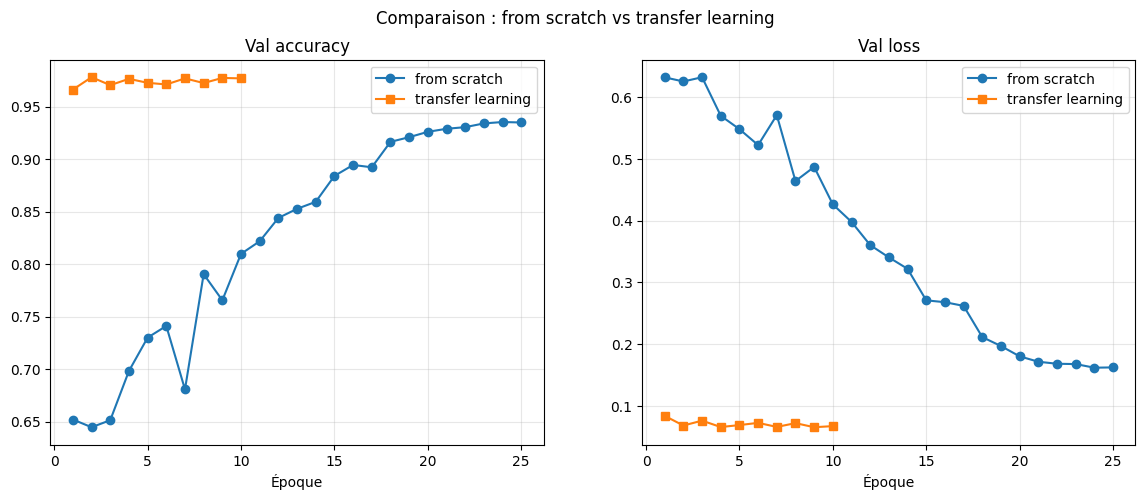

In [26]:
# On retient la meilleure variante de chaque approche
best_scratch_hist = hist_scratch_adam if best_scratch_adam >= best_scratch_sgd else hist_scratch_sgd
best_tf_hist      = hist_tf_adam      if best_tf_adam      >= best_tf_sgd      else hist_tf_adam

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Accuracy
axes[0].plot(range(1, len(best_scratch_hist["val_acc"]) + 1),
             best_scratch_hist["val_acc"], "o-", label="from scratch")
axes[0].plot(range(1, len(best_tf_hist["val_acc"]) + 1),
             best_tf_hist["val_acc"], "s-", label="transfer learning")
axes[0].set_title("Val accuracy"); axes[0].set_xlabel("Époque")
axes[0].legend(); axes[0].grid(alpha=0.3)
# Loss
axes[1].plot(range(1, len(best_scratch_hist["val_loss"]) + 1),
             best_scratch_hist["val_loss"], "o-", label="from scratch")
axes[1].plot(range(1, len(best_tf_hist["val_loss"]) + 1),
             best_tf_hist["val_loss"], "s-", label="transfer learning")
axes[1].set_title("Val loss"); axes[1].set_xlabel("Époque")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle("Comparaison : from scratch vs transfer learning")
plt.show()

In [27]:
# Tableau récapitulatif des meilleures performances en validation
import pandas as pd
recap = pd.DataFrame({
    "Expérience":   ["scratch + Adam", "scratch + SGD", "transfer + Adam", "transfer + SGD"],
    "best val acc": [best_scratch_adam, best_scratch_sgd, best_tf_adam, best_tf_sgd],
})
recap

,Expérience,best val acc
0,scratch + Adam,0.935333
1,scratch + SGD,0.799333
2,transfer + Adam,0.978000
3,transfer + SGD,0.978222


## 2.6 Test final : rechargement du meilleur modèle + matrice de confusion

On **recharge** le meilleur modèle sauvegardé (ici la meilleure variante du
transfer learning) et on l'évalue sur le **jeu de test**, qui n'a jamais servi
pendant l'entraînement. On affiche la matrice de confusion et quelques erreurs.


In [28]:
# Rechargement du meilleur modèle de transfer learning
best_tf_ckpt = "transfer_adam.pth" if best_tf_adam >= best_tf_sgd else "transfer_sgd.pth"

final_model = build_resnet18(num_classes=2, dropout=0.4, freeze=True)
checkpoint = torch.load(best_tf_ckpt, map_location=device)
final_model.load_state_dict(checkpoint["model_state"])
final_model.to(device)
print(f"Modèle rechargé depuis {best_tf_ckpt} "
      f"(val acc sauvegardée = {checkpoint['val_acc']:.4f})")

# Évaluation sur le jeu de test
results = evaluate_full(final_model, testloader)
print(f"\n=== TEST FINAL ===")
print(f"accuracy  = {results['accuracy']:.4f}")
print(f"précision = {results['precision']:.4f}")
print(f"recall    = {results['recall']:.4f}")

Modèle rechargé depuis transfer_sgd.pth (val acc sauvegardée = 0.9782)

=== TEST FINAL ===
accuracy  = 0.9784
précision = 0.9784
recall    = 0.9784


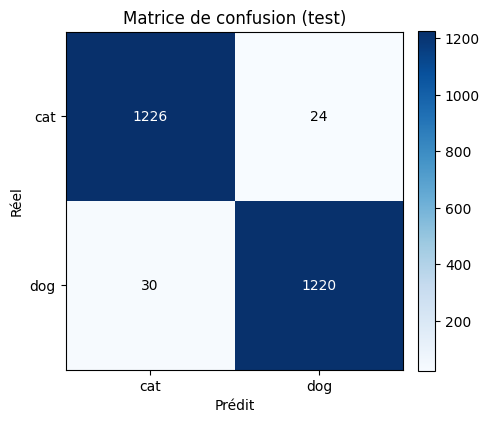

In [29]:
# Matrice de confusion
cm = results["cm"]
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes); ax.set_yticklabels(classes)
ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
ax.set_title("Matrice de confusion (test)")
seuil = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > seuil else "black")
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

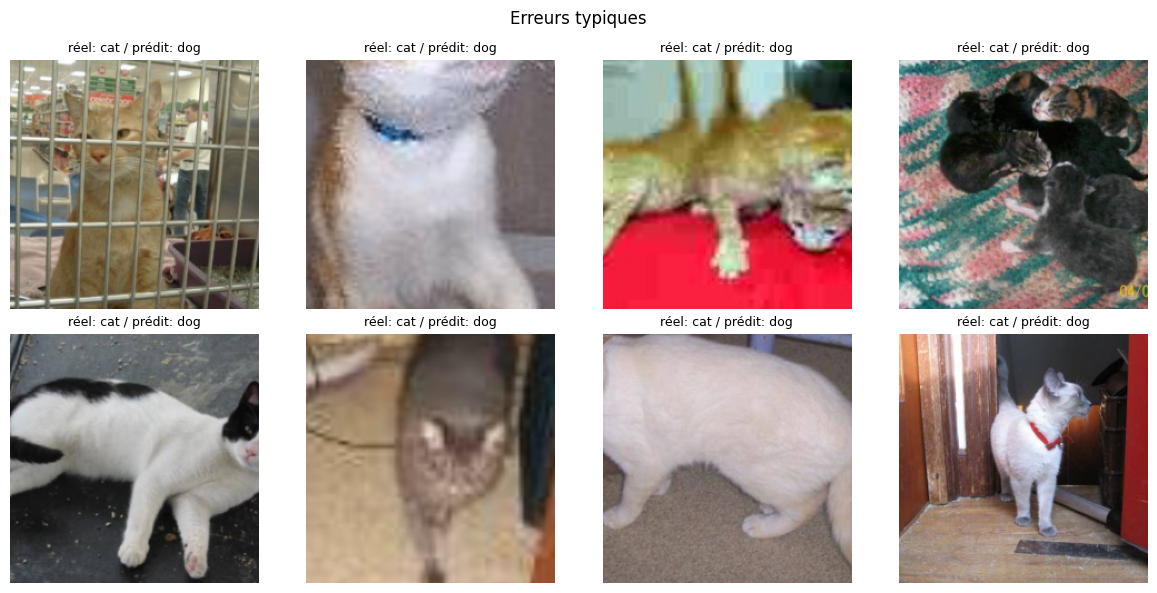

In [30]:
# Quelques erreurs typiques (images mal classées)
final_model.eval()
wrong = []
with torch.no_grad():
    for images, labels in testloader:
        preds = final_model(images.to(device)).argmax(dim=1).cpu()
        for img, t, p in zip(images, labels, preds):
            if t != p:
                wrong.append((img, int(t), int(p)))
        if len(wrong) >= 8:
            break

if wrong:
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for ax, (img, t, p) in zip(axes.ravel(), wrong[:8]):
        imshow(img, ax=ax, normalize=True)
        ax.set_title(f"réel: {classes[t]} / prédit: {classes[p]}", fontsize=9)
    plt.suptitle("Erreurs typiques")
    plt.tight_layout(); plt.show()
else:
    print("Aucune image mal classée dans les lots examinés.")

## 2.7 Analyse et conclusion

### Récapitulatif des résultats

| Expérience | Époques | Meilleure val accuracy |
|---|---|---|
| CNN from scratch + Adam | 25 | **0.9353** |
| CNN from scratch + SGD | 25 | 0.7993 |
| Transfer learning (ResNet18) + Adam | 10 | 0.9780 |
| Transfer learning (ResNet18) + SGD | 10 | **0.9782** |

**Test final** (meilleur modèle, transfer + SGD, rechargé depuis le checkpoint,
évalué sur les 2500 images de test jamais vues) :

- **Accuracy = 0.9784**, **Précision = 0.9784**, **Recall = 0.9784**
- Matrice de confusion : 1226 chats et 1220 chiens correctement classés ;
  seulement 24 chats prédits comme chiens et 30 chiens prédits comme chats
  (54 erreurs sur 2500 images).

### Convergence

Le transfer learning converge de façon spectaculairement plus rapide. Dès la
**première époque**, le modèle ResNet18 atteint déjà environ 0.97 de val
accuracy, alors que le CNN from scratch part de 0.65 et a besoin de l'ensemble
des 25 époques pour approcher 0.93. C'est l'illustration directe du principe du
transfert : les caractéristiques visuelles apprises sur ImageNet (contours,
textures, formes) sont immédiatement réutilisables pour distinguer chats et
chiens, alors que le réseau from scratch doit les apprendre de zéro.

### Performance

Sur la performance finale, le transfer learning domine nettement : ~0.978 de val
accuracy contre ~0.935 pour le meilleur CNN from scratch, soit environ 4 points
d'écart, et l'écart serait bien plus grand à nombre d'époques égal (le transfer
atteint son palier en 1-2 époques). Le test final à 0.9784 confirme que le
modèle généralise très bien sur des données jamais vues.

### Robustesse et régularisation

Un point notable sur les courbes du CNN from scratch : la **val accuracy reste
au-dessus de la train accuracy** (et la val loss sous la train loss). Cela
s'explique par l'augmentation de données et le Dropout, qui rendent les images
d'entraînement plus difficiles que celles de validation. Loin d'être un
problème, c'est le signe d'une bonne régularisation : le modèle ne surapprend
pas et conserve une marge de progression. La BatchNorm a par ailleurs stabilisé
l'entraînement et permis une montée régulière de la performance.

### Effet de l'optimiseur

L'optimiseur a un effet très différent selon la difficulté de la tâche :

- **Pour le CNN from scratch**, Adam (0.935) surpasse largement SGD (0.799).
  La courbe « Adam vs SGD » montre que SGD plafonne tôt vers 0.80 alors qu'Adam
  continue de progresser jusqu'à 0.935. Sur un réseau profond entraîné de zéro,
  le pas adaptatif d'Adam aide à traverser un paysage d'optimisation difficile.
- **Pour le transfer learning**, les deux optimiseurs sont quasi équivalents
  (0.978 chacun), car la seule partie entraînée est la petite tête de
  classification : la tâche d'optimisation est simple et les deux méthodes la
  résolvent aussi bien.

### Recherche du learning rate

Le LR finder a confirmé qu'un learning rate de l'ordre de 1e-3 se situe dans la
zone où la loss décroît avant de diverger (la courbe remonte fortement au-delà
de ~1e-2), ce qui a guidé le choix des learning rates utilisés.

### Erreurs typiques

Les 54 erreurs sur 2500 images correspondent souvent à des cas ambigus :
animaux partiellement visibles, cadrage en gros plan sur une partie du corps,
ou postures inhabituelles. Ces situations restent difficiles même pour un modèle
performant, car elles offrent peu d'indices discriminants.

### Limites et pistes d'amélioration

- **Fine-tuning progressif** du backbone ResNet18 (dégeler les dernières couches
  avec un learning rate faible) pourrait encore améliorer le transfer.
- **Augmentation plus riche** (MixUp, CutMix) et **early stopping** pour le CNN
  from scratch.
- Un **backbone plus puissant** (EfficientNet) ou une **validation croisée**
  donneraient une estimation plus robuste.

### Conclusion

Le transfer learning s'impose clairement sur ce problème : il atteint une
meilleure performance (0.978 vs 0.935), converge en quelques époques au lieu de
plusieurs dizaines, et généralise excellemment (0.9784 sur le test). Le CNN
from scratch reste un exercice instructif et obtient un résultat honorable
(0.935 avec Adam), mais au prix d'un entraînement bien plus long. Cette
comparaison illustre pourquoi le transfer learning est devenu la pratique
standard en vision par ordinateur lorsqu'on dispose d'un backbone pré-entraîné.
